In [47]:
import pandas as pd

data = pd.read_csv("data/U4_01_housing.csv")

In [48]:
# Bikin kolom baru: rata-rata orang per rumah
data = data[data['households'] > 0]  
data['pop_per_household'] = data['population'] / data['households']

In [49]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,pop_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,2.181467


<Axes: xlabel='latitude', ylabel='longitude'>

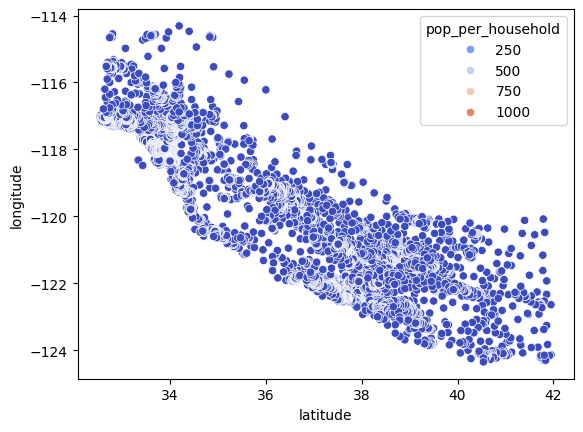

In [50]:
import seaborn as sb 
sb.scatterplot(x="latitude", y="longitude", data=data, hue="pop_per_household", palette="coolwarm")

<Axes: xlabel='latitude', ylabel='longitude'>

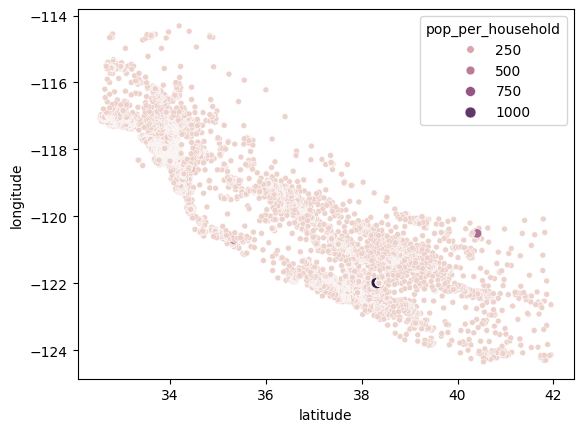

In [51]:
import seaborn as sb 
sb.scatterplot(x="latitude", y="longitude", data=data, hue="pop_per_household", size=data["pop_per_household"])

In [52]:
data.loc[:, ["latitude", "longitude", "pop_per_household"]]

,latitude,longitude,pop_per_household
0,37.88,-122.23,2.555556
1,37.86,-122.22,2.109842
2,37.85,-122.24,2.802260
3,37.85,-122.25,2.547945
4,37.85,-122.25,2.181467
...,...,...,...
20635,39.48,-121.09,2.560606
20636,39.49,-121.21,3.122807
20637,39.43,-121.22,2.325635
20638,39.43,-121.32,2.123209


In [53]:
from sklearn.cluster import KMeans

X = data.loc[:, ["latitude", "longitude", "pop_per_household"]]
model = KMeans(n_clusters=6)
prediksi = model.fit_predict(X)

In [54]:
prediksi.shape

(20640,)

In [55]:
X["living_cluster"] = prediksi

In [56]:
X

,latitude,longitude,pop_per_household,living_cluster
0,37.88,-122.23,2.555556,3
1,37.86,-122.22,2.109842,3
2,37.85,-122.24,2.802260,3
3,37.85,-122.25,2.547945,3
4,37.85,-122.25,2.181467,3
...,...,...,...,...
20635,39.48,-121.09,2.560606,3
20636,39.49,-121.21,3.122807,3
20637,39.43,-121.22,2.325635,3
20638,39.43,-121.32,2.123209,3


In [57]:
X["living_cluster"].value_counts()

living_cluster
5    8717
3    8276
0    3643
1       2
4       1
2       1
Name: count, dtype: int64

<Axes: xlabel='latitude', ylabel='longitude'>

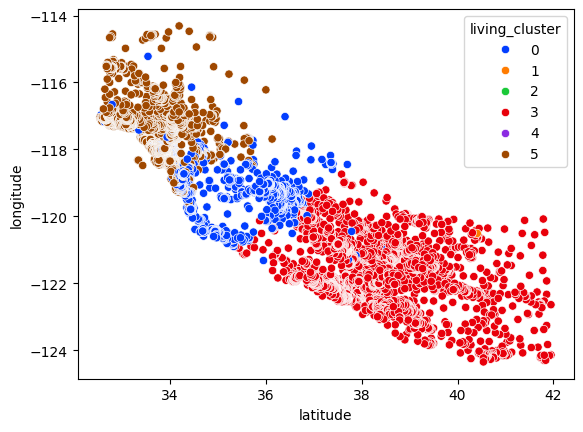

In [58]:
import seaborn as sb 
sb.scatterplot(x="latitude", y="longitude", data=X, hue="living_cluster", palette="bright")

<Axes: xlabel='living_cluster', ylabel='count'>

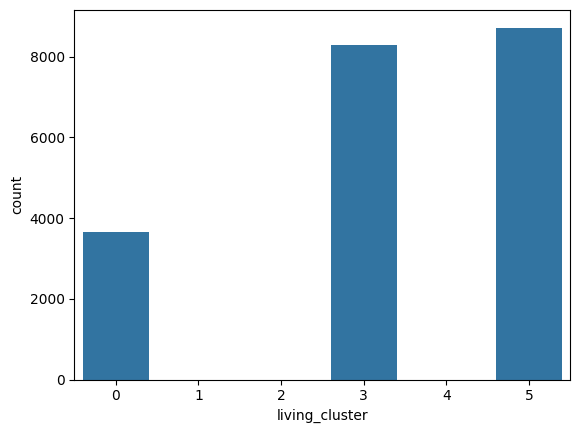

In [59]:
sb.countplot(x="living_cluster", data=X)

In [60]:
X.groupby(["living_cluster"])["pop_per_household"].mean()

living_cluster
0       3.886217
1     551.087912
2    1243.333333
3       2.750417
4     230.172414
5       2.739785
Name: pop_per_household, dtype: float64